# Compare **DynaBatch** vs **Normal** vs **Bucket** vs **MaxToken** Dataloader
We will be using **3** models with **4** different Dataloaders for comparison

| | **NLLB-200-3.3B** | **Qwen3.5-9B** | **m2m100-418M** |
| :--- | :---: | :---: | :---: |
| **Normal** | ✔ | ✔ | ✔ |
| **Bucket** | ✔ | ✔ | ✔ |
| **Max Token** | ✔ | ✔ | ✔ |
| **DynaBatch** | ✔ | ✔ | ✔ |



In [ ]:
#@title Install Packages
!pip install transformers==5.5.0
!pip install bitsandbytes==0.49.2 accelerate peft
!pip install dynabatch
!pip install hf_transfer

**Imports and load Data**

In [ ]:
#@title Imports and load Data

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer
from transformers import AutoProcessor, AutoModelForCausalLM, BitsAndBytesConfig
import torch
from tqdm import tqdm
from datasets import load_dataset
from dynabatch import build_dynabatch_dataloader, dynabatch_sampler
import torch
from torch.utils.data import Dataset, DataLoader, Sampler
from datetime import datetime
import numpy as np
import gc
import random
import pandas as pd
from IPython.display import display
import os

random.seed(21)
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

###################################
# Load Data
# load data
ds = load_dataset("OpenAssistant/oasst1")
df = ds['train'].to_pandas()
wanted_langs = ["en", "de", "ru", "es"]
wanted_cols = ["text", "lang"]
df = df[df['lang'].isin(wanted_langs)]
df = df[wanted_cols]
device = torch.device("cuda")
df_es = df[df['lang'] == 'es']
df_en = df[df['lang'] == 'en']
df_ru = df[df['lang'] == 'ru']
df_de = df[df['lang'] == 'de']

###################################
# Color codes: For printing purpose
GREEN = "\033[92m"
RED = "\033[91m"
RESET = "\033[0m"

In [3]:
#@title Utility Functions

###################################
# Vanilla Bucket Sampler
class BucketSampler(Sampler):
    def __init__(self, data, batch_size):
        self.batch_size = batch_size
        self.lengths = np.array([len(text) for text in data])
        self.indices = np.argsort(self.lengths)

    def __iter__(self):
        batches = [
            self.indices[i : i + self.batch_size].tolist()
            for i in range(0, len(self.indices), self.batch_size)
        ]
        for batch in batches:
            yield from batch

    def __len__(self):
        return len(self.lengths)

###################################
# Utility functions for printing purpose
def color_speedup(val):
    val_rounded = round(val, 2)
    if val_rounded > 1.00:
        color = 'green'
    elif val_rounded < 1.00:
        color = 'red'
    else:
        color = 'gray'
    return f'color: {color}; font-weight: bold'

def style_display(normal_ratio, bucket_ratio, max_token_ratio, model_name, batch_size, model):
    print(f"📊 Model: \t\t{model_name}")
    print(f"💾 Memory footprint: \t{model.get_memory_footprint() / 1e9:.2f} GB")
    print(f"📦 Batch Size: \t\t{batch_size}\n")
    df = pd.DataFrame({
        "Baseline Dataloader": ["Normal", "Bucket Sampler", "MaxToken Sampler (Dynabatch)"],
        "Speedup vs Baseline": [normal_ratio, bucket_ratio, max_token_ratio]
    })
    styled_df = (
        df.style
        .format({"Speedup vs Baseline": "{:.2f}x"})
        .map(color_speedup, subset=["Speedup vs Baseline"])
        .hide(axis="index")
    )
    display(styled_df)

###################################
# Inference given a custom dataloader
def inference(custom_dataloader, **gen_kwargs):
    model.eval()
    start_time = datetime.now()
    with torch.inference_mode():
      for i, batch in tqdm(enumerate(custom_dataloader), total=len(custom_dataloader)):
          input_ids = batch["input_ids"].to(device)
          attention_mask = batch["attention_mask"].to(device)
          generated_tokens = model.generate(
              input_ids=input_ids,
              attention_mask=attention_mask,
              **gen_kwargs
          )
    time_taken = (datetime.now() - start_time).total_seconds()
    # Clear allocated memory
    del input_ids, attention_mask, generated_tokens
    gc.collect()
    torch.cuda.empty_cache()
    return time_taken

In [4]:
if torch.cuda.is_available():
    print(f"✅ Using Collab GPU: {torch.cuda.get_device_name(0)}")
else:
    print("❌ No GPU found. Change runtime type to GPU.")

✅ Using Collab GPU: Tesla T4


# 1️⃣  Model: M2M100 418M

In [5]:
#@title Load Model and Config | Batch Size = 64 | samples = 1000 | max_length = 512

###################################
# Load Model, Tokenizer
model_id = "facebook/m2m100_418M"
model = M2M100ForConditionalGeneration.from_pretrained(model_id, torch_dtype=torch.float16, device_map={"": device})
tokenizer = M2M100Tokenizer.from_pretrained(model_id, src_lang="es", tgt_lang="en")

###################################
# Data, Config
max_length   = 512
data_samples = 1000
batch_size   = 64 # 64 Max it can handle for all dataloaders
texts_data   = df_es["text"].sample(data_samples, random_state=21).tolist()

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [ ]:
#@title 1.1 Dynabatch Dataloader

# Two ways to create a Dynabatch Dataloader
# 1. using directly build_dynabatch_dataloader from dynabatch
dynabatch_loader = build_dynabatch_dataloader(
    texts_data,
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_input_token_length=max_length,
)

# 2. dynabatch_sampler + DataLoader (more control over dataset / collate).
#    Use batch_sampler=sampler — not sampler= — and omit batch_size on the loader.
# sampler = dynabatch_sampler(
#     texts=texts_data,
#     tokenizer=tokenizer,
#     batch_size=batch_size,
#     max_input_token_length=max_length,
# )
# dynabatch_loader_2 = DataLoader(
#     text_ds,  # Dataset with len == len(texts_data), same index order as `texts`
#     batch_sampler=sampler,
#     collate_fn=lambda batch: tokenizer(
#         text=[item["text"] for item in batch],
#         padding=True,
#         truncation=True,
#         return_tensors="pt",
#         max_length=max_length,
#     ),
# )

m2m_dynabatch_time_taken = inference(dynabatch_loader)


Step 1: tokenizing and measuring lengths (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

100%|██████████| 12/12 [04:18<00:00, 21.54s/it]


In [ ]:
#@title 1.2 Max-Token Dataloader

maxtoken_loader = build_dynabatch_dataloader(
    texts_data,
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_input_token_length=max_length,
    dynamic_batch_mode = False, # <---------------------- This flag makes it run as a Max Token Batch Sampler
)
m2m_maxtoken_time_taken = inference(maxtoken_loader)



Step 1: tokenizing and measuring lengths (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

100%|██████████| 16/16 [04:34<00:00, 17.16s/it]


In [8]:
#@title 1.3 Bucket Dataloader

bucket_sampler = BucketSampler(texts_data, batch_size)
bucket_loader = DataLoader(
    texts_data,
    batch_size=batch_size,
    sampler=bucket_sampler,
    collate_fn=lambda batch: tokenizer(text=batch, padding=True, truncation=True, return_tensors="pt", max_length=max_length)
)
m2m_bucket_time_taken = inference(bucket_loader)

100%|██████████| 16/16 [05:20<00:00, 20.02s/it]


In [9]:
#@title 1.4 Normal Dataloader

normal_loader = DataLoader(
    texts_data,
    batch_size=batch_size,
    collate_fn=lambda batch: tokenizer(text=batch, padding=True, truncation=True, return_tensors="pt", max_length=max_length)
)
m2m_normal_time_taken = inference(normal_loader)

100%|██████████| 16/16 [13:24<00:00, 50.29s/it]


In [10]:
#@title 1.5 Compare Time Taken
m2m_normal_ratio    = m2m_normal_time_taken    / m2m_dynabatch_time_taken
m2m_bucket_ratio    = m2m_bucket_time_taken    / m2m_dynabatch_time_taken
m2m_max_token_ratio = m2m_maxtoken_time_taken  / m2m_dynabatch_time_taken

style_display(m2m_normal_ratio, m2m_bucket_ratio, m2m_max_token_ratio, "M2M100 418M", batch_size, model)
del model, tokenizer, normal_loader, bucket_sampler, maxtoken_loader, dynabatch_loader
gc.collect()
torch.cuda.empty_cache()

📊 Model: 		M2M100 418M
💾 Memory footprint: 	0.97 GB
📦 Batch Size: 		64



Baseline Dataloader,Speedup vs Baseline
Normal,3.11x
Bucket Sampler,1.24x
MaxToken Sampler (Dynabatch),1.06x


# 2️⃣ Model: **Qwen 3.5 - 9B**

In [ ]:
#@title Load Model and Config | Batch Size = 20 | samples = 1000 | max_length = 512

###################################
# Load Model, Tokenizer | Takes 10-16 min to download and load
model_id = "Qwen/Qwen3.5-9B"
# Loading in 8bit Since FP 16 cannot be fit inside a T4 GPU
quantization_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0,
    llm_int8_has_fp16_weight=False
)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map={"": device},
    quantization_config=quantization_config,
    dtype=torch.bfloat16,
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(model_id)

###################################
# Other utils
def add_chat_template(texts):
    batch_messages = [
        [
            {"role": "system", "content": "Translate English to Dutch"},
            {"role": "user", "content": text}
        ]
        for text in texts
    ]
    return tokenizer.apply_chat_template(batch_messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)

###################################
# Data, Config
max_length   = 512
data_samples = 1000
batch_size   = 20 # 20 Max it can handle for all dataloaders
df_de_sample = df_de.sample(data_samples, random_state=21)['text'].to_list()
texts_data   = add_chat_template(df_de_sample)


In [ ]:
#@title 2.1 Dynabatch Dataloader

dynabatch_loader = build_dynabatch_dataloader(
    texts_data,
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_input_token_length=max_length,
)
qwen_dynabatch_time_taken = inference(dynabatch_loader)


Step 1: tokenizing and measuring lengths (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]


Step 2: building dynamic batches: 100%|██████████| 980/980 [00:00<00:00, 1247.63seq/s]

  0%|          | 0/36 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=532) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")

  3%|▎         | 1/36 [00:30<17:31, 30.05s/it]Setting `pad_token

In [ ]:
#@title 2.2  Max-Token Dataloader (via Dynabatch)

maxtoken_loader = build_dynabatch_dataloader(
    texts_data,
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_input_token_length=max_length,
    dynamic_batch_mode = False, # <---------------------- This flag makes it run as a Max Token Batch Sampler
)
qwen_maxtoken_time_taken = inference(maxtoken_loader)


Step 1: tokenizing and measuring lengths (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

  0%|          | 0/50 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=532) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
  2%|▏         | 1/50 [00:24<20:02, 24.54s/it]Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
A decoder-only architecture is bein

In [14]:
#@title 2.3  Bucket Dataloader

bucket_sampler = BucketSampler(texts_data, batch_size)
bucket_loader = DataLoader(
    texts_data,
    batch_size=batch_size,
    sampler=bucket_sampler,
    collate_fn=lambda batch: tokenizer(text=batch, padding=True, truncation=True, return_tensors="pt", max_length=max_length)
)
qwen_bucket_time_taken = inference(bucket_loader)

  0%|          | 0/50 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
  2%|▏         | 1/50 [00:08<06:48,  8.33s/it]Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
  4%|▍         | 2/50 [00:16<06:26,  8.06s/it]Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
  6%|▌         | 3/50 [00:24<06:19,  8.08s/it]Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
A decoder-onl

In [15]:
#@title 2.4  Normal Dataloader
normal_loader = DataLoader(
    texts_data,
    batch_size=batch_size,
    collate_fn=lambda batch: tokenizer(text=batch, padding=True, truncation=True, return_tensors="pt", max_length=max_length)
)
qwen_normal_time_taken = inference(normal_loader)


  0%|          | 0/50 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
  2%|▏         | 1/50 [00:22<18:10, 22.26s/it]Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=469) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
  4%|▍         | 2/50 [00:42<16:59, 21.25s/it]Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
A decoder-only archite

In [16]:
#@title 2.5  Compare Time Taken
qwen_normal_ratio    = qwen_normal_time_taken    / qwen_dynabatch_time_taken
qwen_bucket_ratio    = qwen_bucket_time_taken    / qwen_dynabatch_time_taken
qwen_max_token_ratio = qwen_maxtoken_time_taken  / qwen_dynabatch_time_taken

style_display(qwen_normal_ratio, qwen_bucket_ratio, qwen_max_token_ratio, "Qwen-3.5 9B", batch_size, model)
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()

📊 Model: 		Qwen-3.5 9B
💾 Memory footprint: 	10.99 GB
📦 Batch Size: 		20



Baseline Dataloader,Speedup vs Baseline
Normal,1.95x
Bucket Sampler,1.22x
MaxToken Sampler (Dynabatch),1.13x


# 3️⃣ Model: Model: **NLLB-200-3.3B**

In [ ]:
#@title Load Model and Config | Batch Size = 48 | samples = 1500 | max_length = 512

###################################
# Load Model, Tokenizer | Takes 6-9 min to download and load
model_name = "facebook/nllb-200-3.3B"
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map={"": device}
)
model = torch.compile(model)
tokenizer = AutoTokenizer.from_pretrained(model_name, src_lang="eng_Latn", tgt_lang="fra_Latn")

###################################
# Data and Configs
data_samples = 1500
batch_size   = 48 # 48 is the Maximum size the T4 15.3 Gb can take
max_length   = 512

texts_data = df_en["text"].sample(data_samples, random_state=21).tolist()

In [ ]:
#@title 3.1 Dynabatch Dataloader
dynabatch_loader = build_dynabatch_dataloader(
    texts_data,
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_input_token_length=max_length,
)
nllb_dynabatch_time_taken = inference(dynabatch_loader)


Step 1: tokenizing and measuring lengths (num_proc=2):   0%|          | 0/1500 [00:00<?, ? examples/s]

100%|██████████| 23/23 [04:51<00:00, 12.65s/it]


In [ ]:
#@title 3.2 Max-Token Dataloader (via Dynabatch)

maxtoken_loader = build_dynabatch_dataloader(
    texts_data,
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_input_token_length=max_length,
    dynamic_batch_mode = False, # <---------------------- This flag makes it run as a Max Token Batch Sampler
)
nllb_maxtoken_time_taken = inference(maxtoken_loader)


Step 1: tokenizing and measuring lengths (num_proc=2):   0%|          | 0/1500 [00:00<?, ? examples/s]

100%|██████████| 32/32 [05:53<00:00, 11.04s/it]


In [20]:
#@title 3.3 Bucket Dataloader
bucket_sampler = BucketSampler(texts_data, batch_size)
bucket_loader = DataLoader(
    texts_data,
    batch_size=batch_size,
    sampler=bucket_sampler,
    collate_fn=lambda batch: tokenizer(text=batch, padding=True, truncation=True, return_tensors="pt", max_length=max_length)
)
nllb_bucket_time_taken = inference(bucket_loader)

100%|██████████| 32/32 [06:27<00:00, 12.10s/it]


In [21]:
#@title 3.4 Normal Dataloader
normal_loader = DataLoader(
    texts_data,
    batch_size=batch_size,
    collate_fn=lambda batch: tokenizer(text=batch, padding=True, truncation=True, return_tensors="pt", max_length=max_length)
)
nllb_normal_time_taken = inference(normal_loader)

100%|██████████| 32/32 [09:01<00:00, 16.91s/it]


In [22]:
#@title 3.5 Compare Time Taken
nllb_normal_ratio    = nllb_normal_time_taken    / nllb_dynabatch_time_taken
nllb_bucket_ratio    = nllb_bucket_time_taken    / nllb_dynabatch_time_taken
nllb_max_token_ratio = nllb_maxtoken_time_taken  / nllb_dynabatch_time_taken

style_display(nllb_normal_ratio, nllb_bucket_ratio, nllb_max_token_ratio, "NLLB-200 3.3B", batch_size, model)
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()

📊 Model: 		NLLB-200 3.3B
💾 Memory footprint: 	6.70 GB
📦 Batch Size: 		48



Baseline Dataloader,Speedup vs Baseline
Normal,1.86x
Bucket Sampler,1.33x
MaxToken Sampler (Dynabatch),1.21x


# 📊 Consildate Comparison Table

Model,Dataloader,Time (s),Speedup vs DynaBatch
NLLB-200,Normal,541s,1.86x
NLLB-200,Bucket,387s,1.33x
NLLB-200,MaxToken,353s,1.21x
,,,
Qwen3.5,Normal,946s,1.95x
Qwen3.5,Bucket,592s,1.22x
Qwen3.5,MaxToken,552s,1.13x
,,,
M2M100,Normal,805s,3.11x
M2M100,Bucket,320s,1.24x


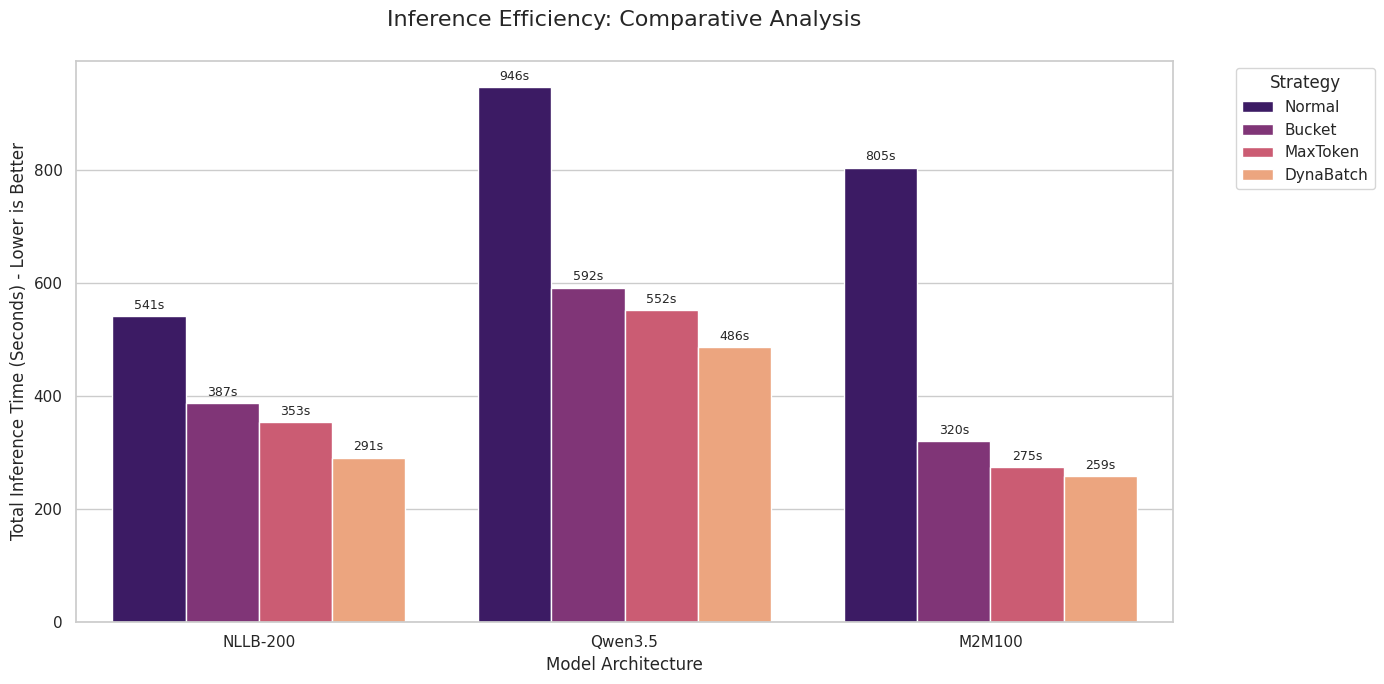

In [23]:
#@title Display Graphs and Table

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare and Display Summary Table
# Re-calculating or using existing ratios for the table
data_table = {
    "Model": ["NLLB-200", "NLLB-200", "NLLB-200", "",
              "Qwen3.5", "Qwen3.5", "Qwen3.5", "",
              "M2M100", "M2M100", "M2M100"],
    "Dataloader": ["Normal", "Bucket", "MaxToken", "",
                   "Normal", "Bucket", "MaxToken", "",
                   "Normal", "Bucket", "MaxToken"],
    "Time (s)": [
        nllb_normal_time_taken, nllb_bucket_time_taken, nllb_maxtoken_time_taken, np.nan,
        qwen_normal_time_taken, qwen_bucket_time_taken, qwen_maxtoken_time_taken, np.nan,
        m2m_normal_time_taken, m2m_bucket_time_taken, m2m_maxtoken_time_taken
    ],
    "Speedup vs DynaBatch": [
        nllb_normal_ratio, nllb_bucket_ratio, nllb_max_token_ratio, np.nan,
        qwen_normal_ratio, qwen_bucket_ratio, qwen_max_token_ratio, np.nan,
        m2m_normal_ratio, m2m_bucket_ratio, m2m_max_token_ratio
    ]
}

df_summary = pd.DataFrame(data_table).fillna("")

styled_summary = (
    df_summary.style
    .format({
        "Time (s)": lambda x: f"{x:.0f}s" if isinstance(x, (int, float)) else "",
        "Speedup vs DynaBatch": lambda x: f"{x:.2f}x" if isinstance(x, (int, float)) else ""
    })
    .map(color_speedup, subset=pd.IndexSlice[df_summary["Speedup vs DynaBatch"] != "", "Speedup vs DynaBatch"])
    .set_caption("### Performance Summary Table")
    .hide(axis="index")
)
display(styled_summary)

# 2. Prepare and Display Comparison Chart
plot_data = pd.DataFrame({
    "Model": ["NLLB-200", "NLLB-200", "NLLB-200", "NLLB-200",
              "Qwen3.5", "Qwen3.5", "Qwen3.5", "Qwen3.5",
              "M2M100", "M2M100", "M2M100", "M2M100"],
    "Dataloader": ["Normal", "Bucket", "MaxToken", "DynaBatch",
                    "Normal", "Bucket", "MaxToken", "DynaBatch",
                    "Normal", "Bucket", "MaxToken", "DynaBatch"],
    "Time (Seconds)": [
        nllb_normal_time_taken, nllb_bucket_time_taken, nllb_maxtoken_time_taken, nllb_dynabatch_time_taken,
        qwen_normal_time_taken, qwen_bucket_time_taken, qwen_maxtoken_time_taken, qwen_dynabatch_time_taken,
        m2m_normal_time_taken, m2m_bucket_time_taken, m2m_maxtoken_time_taken, m2m_dynabatch_time_taken
    ]
})

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=plot_data, x="Model", y="Time (Seconds)", hue="Dataloader", palette="magma")

plt.title("Inference Efficiency: Comparative Analysis", fontsize=16, pad=25)
plt.ylabel("Total Inference Time (Seconds) - Lower is Better", fontsize=12)
plt.xlabel("Model Architecture", fontsize=12)
plt.legend(title="Strategy", bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0fs', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## OOM-safe generation Fallback **`inference_nllb_with_OOM_handle()`**
The regressor is empirical, so it can still occasionally predict a batch size that turns out too aggressive for a specific model, prompt template, GPU state, or generation setting. generate_with_oom_fallback() lets you keep the run alive by splitting only the failed batch into smaller chunks.

This is useful when you want throughput from dynamic batching without letting one occasional OOM kill a long inference run.


In [ ]:
# from dynabatch import generate_with_oom_fallback

# dynabatch_loader = build_dynamic_batch_dataloader(
#     texts_data,
#     tokenizer=tokenizer,
#     batch_size=batch_size,
#     max_input_token_length=max_length,
# )

# # One limitation of dynabatch is that sometimes the dynabatch model may incorrectly
# # predicts bigger batch size, leading to GPU OOM error. To workaround this
# # without interrupting the flow of inference/training, we use generate_with_oom_fallback
# # which splits the batch into smaller chunks and merges results back.
# # NOTE: If there are too many fails, recommended to reduce the batch size as the might slow down the generation
# with torch.inference_mode():
#     for i, batch in tqdm(enumerate(dynabatch_loader), total=len(dynabatch_loader)):
#         generated_tokens, did_fallback = generate_with_oom_fallback(
#             model, batch, min_batch_size=min_batch_size, device=device
#         )
#         if did_fallback:
#             failed_times += 1
# print("Total Failed: ", failed_times)